In [ ]:
from src.dataloading import EpiConfig, EpiDataOrchestrator, CrossValidationEpiConfig, FoldCollection

In [ ]:
from src.dataloading import EpiConfig, EpiDataOrchestrator, BaseLineDataLoaderManager, GraphDataLoaderManager
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 12
lag_num         = 4

global_config = EpiConfig(
    disease             = disease_name,

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 

    # quantiles           = [0.1,0.25, 0.5, 0.75, 0.9],
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    lag_column          = 'incidence',  
    verbose             = 0  ,

    feature_popdens     = True,
    feature_popage      = True,
    feature_popsize     = True,
    # feature_climateology= True
    )    

cv_config = CrossValidationEpiConfig(
    min_date            = '2011-06-01',
    max_date            = '2023-06-01',
    num_folds           = 8,
    fold_step           = 1,
    train_periods       = 3,
    val_periods         = 1,
    test_periods        = 1,
    expansion_method    = 'rolling_window',
    unit                = 'y'
)


In [31]:
fold_collection = FoldCollection.build(cv_config, global_config)

data orchestrator per fold: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.86it/s]


In [32]:
from src.dataloading import BaseLineDataLoaderManager

from src.models import PersistenceModel, ClimateologyModel

 Fold  |    Min Date    |   Train/Val    |    Val/Test    |    Max Date   
--------------------------------------------------------------------------
  0    |   2011-06-01   |   2014-06-01   |   2015-06-01   |   2016-06-01  
  1    |   2012-06-01   |   2015-06-01   |   2016-06-01   |   2017-06-01  
  2    |   2013-06-01   |   2016-06-01   |   2017-06-01   |   2018-06-01  
  3    |   2014-06-01   |   2017-06-01   |   2018-06-01   |   2019-06-01  
  4    |   2015-06-01   |   2018-06-01   |   2019-06-01   |   2020-06-01  
  5    |   2016-06-01   |   2019-06-01   |   2020-06-01   |   2021-06-01  
  6    |   2017-06-01   |   2020-06-01   |   2021-06-01   |   2022-06-01  
  7    |   2018-06-01   |   2021-06-01   |   2022-06-01   |   2023-06-01  

<EpiFold(fold_idx = 0, metadata, epiconfig, data_orch)>
<EpiFold(fold_idx = 1, metadata, epiconfig, data_orch)>
<EpiFold(fold_idx = 2, metadata, epiconfig, data_orch)>
<EpiFold(fold_idx = 3, metadata, epiconfig, data_orch)>
<EpiFold(fold_idx = 4, me

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.0759
trained ✓


Forecasting test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 1036.45it/s]


Test loss: 0.1009
forecasted ✓


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1200/1200 [00:01<00:00, 757.08it/s]


best
persistence    0.768
gcn_geo        0.160
climatology    0.072
Name: proportion, dtype: float64

Median margin: 0.1762
model        persistence  climatology  gcn_geo
best                                          
climatology       -0.022        0.066    0.017
gcn_geo            0.060        0.042    0.139
persistence        0.386        0.031    0.122


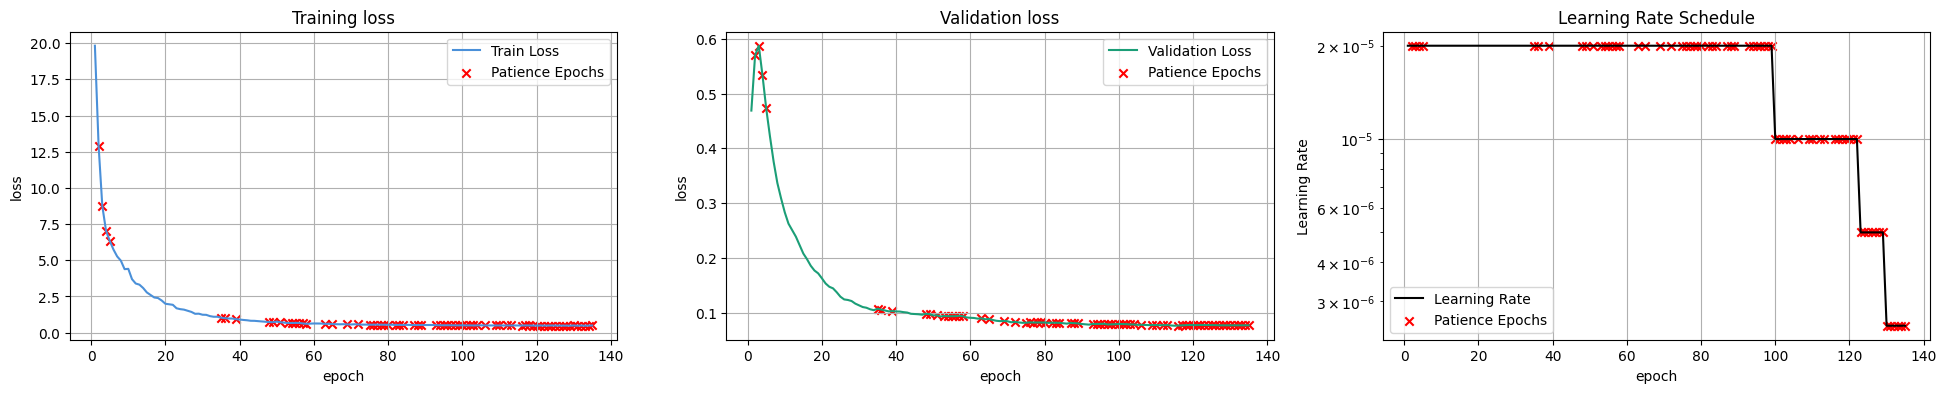

In [68]:
from src.dataloading import BaseLineDataLoaderManager, GraphDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, DecoupledGCNModel, SimpleGCNModel
from src.evaluation import Evaluator

# ── pick a fold ───────────────────────────────────────────────────────────────
fold = fold_collection[6]
print(fold_collection.summary())  # sanity check dates

# ── baselines ─────────────────────────────────────────────────────────────────
baseline_data = BaseLineDataLoaderManager(fold.data_orch)

persistence   = PersistenceModel(baseline_data,  name='persistence')
climatology   = ClimateologyModel(baseline_data, name='climatology')

for m in [persistence, climatology]:
    m.train()
    m.forecast('test')

# ── one GNN to start ──────────────────────────────────────────────────────────
loader = GraphDataLoaderManager(fold.data_orch).retrieve_static_graph('test1').build()
gcn    = SimpleGCNModel(loader, name='gcn_geo', verbose=2)
gcn.set_model_hparams()
gcn.set_global_hparams(lr=0.00002, n_epochs=500, loss='mse', patience=20,
                        scheduler='plateau',
                        scheduler_kwargs={'mode': 'min', 'factor': 0.5, 'patience': 6},
                        min_delta=0.0001)
gcn.train()
gcn.forecast('test')

# ── evaluate ──────────────────────────────────────────────────────────────────
evaluator = Evaluator([persistence, climatology, gcn])
evaluator.add_evaluation(0, 'test')

metrics = evaluator.data_compilation.get_data(0, 'test')['metrics']

# ── quick winner summary ──────────────────────────────────────────────────────
model_cols = ['persistence', 'climatology', 'gcn_geo']

df_wide = (metrics
    .pivot_table(index='nuts_node', columns='model', values='ccc')
    .reset_index())

df_wide['best']   = df_wide[model_cols].idxmax(axis=1)
df_wide['margin'] = df_wide[model_cols].max(axis=1) - df_wide[model_cols].apply(
    lambda r: r.nlargest(2).iloc[1], axis=1)

print(df_wide['best'].value_counts(normalize=True).round(3))
print(f"\nMedian margin: {df_wide['margin'].median():.4f}")
print(df_wide.groupby('best')[model_cols].mean().round(3))

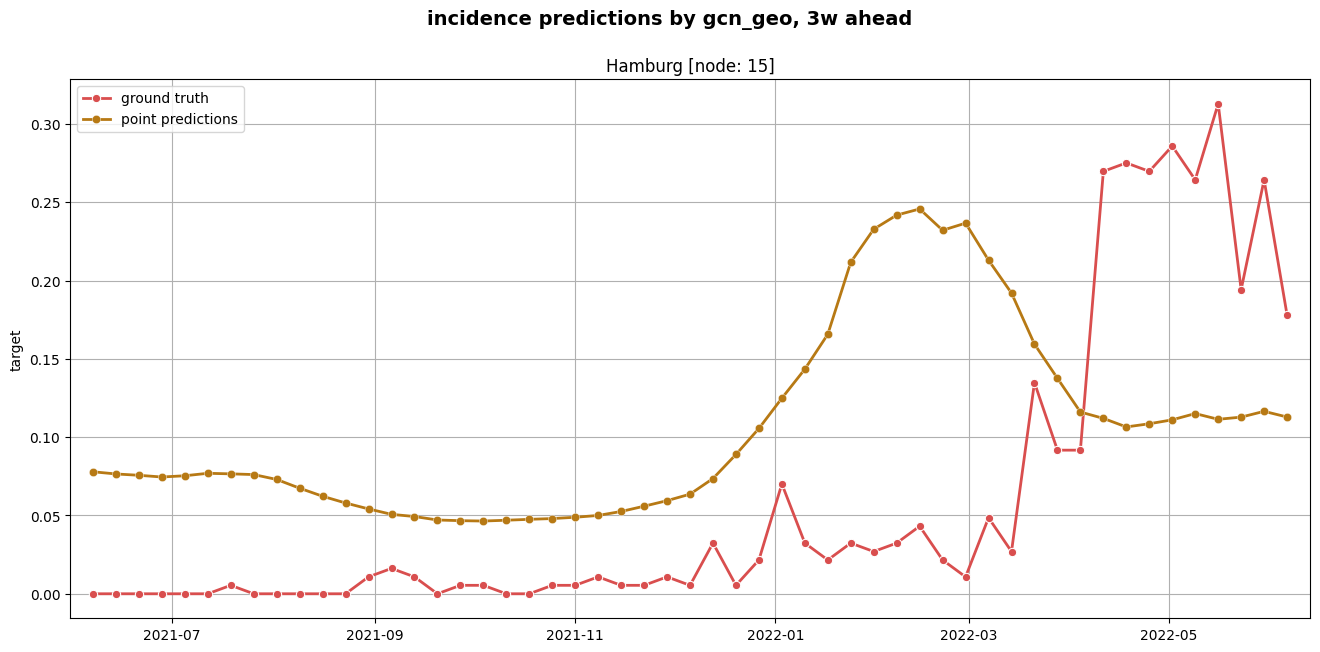

In [71]:
evaluator.evaluated_models['gcn_geo'].show_forecasts(15).show()

In [26]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

persistences    = []
climateologies  = []


for fold_idx, fold in enumerate(fold_collection):
    for model_idx, model in enumerate(models[f'fold{fold_idx + 1}']):
        if model.__class__.__name__ == 'PersistenceModel':
            persistences.append(model)
        if model.__class__.__name__ == 'ClimateologyModel':
            climateologies.append(model)


evaluators_baseline = {
    'persistence':  Evaluator(persistences).add_evaluation(),
    'climateology': Evaluator(climateologies).add_evaluation()
}

figure_raw1 = (evaluators_baseline['persistence'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'persistence', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators_baseline['climateology'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'climateology', fontweight='bold', fontsize=14)
            )


  0%|                                                                                                                                                                                | 0/3200 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3200/3200 [00:04<00:00, 778.39it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


In [ ]:
from src.models import SimpleGCNModel, DecoupledGCNModel
from src.dataloading import GraphDataLoaderManager



deepmodels = {}

for fold_idx, fold in enumerate(fold_collection):
    print(fold_idx)
    
    graphloader1 = GraphDataLoaderManager(fold.data_orch).retrieve_static_graph('test3').build()
    graphloader2 = GraphDataLoaderManager(fold.data_orch).retrieve_static_graph('test2').build()
    graphloader3 = GraphDataLoaderManager(fold.data_orch).retrieve_static_graph('static_commuter24_1').build()

    model1 = DecoupledGCNModel(graphloader1, name = f'spatial1 - fold{fold_idx}', verbose = 2)
    model1.set_model_hparams()
    model1.set_global_hparams(**global_hparams)
    model1.train()
    model1.forecast()

    model2 = DecoupledGCNModel(graphloader2, name = f'spatial2 - fold{fold_idx}', verbose = 2)
    model2.set_model_hparams()
    model2.set_global_hparams(**global_hparams)
    model2.train()
    model2.forecast()

    model3 = DecoupledGCNModel(graphloader3, name = f'spatial3 - fold{fold_idx}', verbose = 2)
    model3.set_model_hparams()
    model3.set_global_hparams(**global_hparams)
    model3.train()
    model3.forecast()


    models_fold = [model1,model2,model3]
    models[f'fold{fold_idx+1}'] = models_fold

KeyboardInterrupt: 

In [28]:
evaluators_gcn

{'spatial1': <Evaluator(models: ['spatial1'],
 	data_compilation: <EvaluationPredictionsCompilation({'test': ['horizon_0']})>)>,
 'spatial2': <Evaluator(models: ['spatial2'],
 	data_compilation: <EvaluationPredictionsCompilation({'test': ['horizon_0']})>)>,
 'spatial3': <Evaluator(models: ['spatial3'],
 	data_compilation: <EvaluationPredictionsCompilation({'test': ['horizon_0']})>)>}

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# ── 1. Collect metrics across all folds ──────────────────────────────────────
# Assumes: evaluators = {f'fold{i+1}': evaluator_obj for i, ...}
# Adjust to however you stored your per-fold evaluators

baseline_models = ['climateology_model', 'persistence_model']  # adjust names to match yours
gnn_models      = ['spatial1', 'spatial2', 'spatial3']
metric          = 'ccc'

all_folds = []
for fold_name, evaluator in evaluators.items():
    metrics_df = evaluator.data_compilation.get_data(0, 'test')['metrics']
    metrics_df = metrics_df[['nuts_node', 'model', metric]].copy()
    metrics_df['fold'] = fold_name
    all_folds.append(metrics_df)

df = pd.concat(all_folds, ignore_index=True)

# ── 2. Wide format: one column per model ─────────────────────────────────────
df_wide = (
    df
    .pivot_table(index=['fold', 'nuts_node'], columns='model', values=metric)
    .reset_index()
)

model_cols = baseline_models + gnn_models

# ── 3. Best GNN per node-fold (single representative GNN) ────────────────────
df_wide['best_gnn']        = df_wide[gnn_models].max(axis=1)   # best GNN score
df_wide['best_gnn_name']   = df_wide[gnn_models].idxmax(axis=1)
df_wide['best_baseline']   = df_wide[baseline_models].max(axis=1)
df_wide['best_overall']    = df_wide[model_cols].max(axis=1)
df_wide['best_overall_name'] = df_wide[model_cols].idxmax(axis=1)
df_wide['margin']          = df_wide['best_overall'] - df_wide[model_cols].apply(
    lambda row: row.nlargest(2).iloc[1], axis=1
)

# ── 4. Winner category: GNN vs baseline ──────────────────────────────────────
df_wide['winner_category'] = df_wide['best_overall_name'].apply(
    lambda m: 'GNN' if m in gnn_models else m
)

# ── 5. Fraction won — per fold and aggregated ─────────────────────────────────
# Per fold
fold_fractions = (
    df_wide.groupby('fold')['winner_category']
    .value_counts(normalize=True)
    .rename('fraction')
    .reset_index()
)
print(fold_fractions.pivot(index='fold', columns='winner_category', values='fraction').round(3))

# Aggregated across folds
overall_fractions = (
    df_wide['winner_category']
    .value_counts(normalize=True)
    .round(3)
)
print("\nOverall winner fractions:")
print(overall_fractions)

# ── 6. Margin distribution by winner ─────────────────────────────────────────
print("\nMargin distribution by winner:")
print(df_wide.groupby('winner_category')['margin'].describe().round(3))

# ── 7. GNN delta over best baseline ──────────────────────────────────────────
# How much does the best GNN beat the best baseline, per node-fold?
df_wide['gnn_delta'] = df_wide['best_gnn'] - df_wide['best_baseline']

print(f"\nGNN delta over best baseline:")
print(df_wide['gnn_delta'].describe().round(4))
print(f"GNN beats best baseline: {(df_wide['gnn_delta'] > 0).mean():.1%} of node-folds")
print(f"GNN beats best baseline by >0.02: {(df_wide['gnn_delta'] > 0.02).mean():.1%} of node-folds")

# ── 8. Does GNN win more on harder nodes? ────────────────────────────────────
# Harder nodes = lower persistence CCC
persistence_ccc = df_wide.pivot_table(
    index='nuts_node', columns='model', values=metric
)['persistence_model'].groupby(level=0).mean()  # mean across folds

df_node = df_wide.groupby('nuts_node').agg(
    gnn_win_rate    = ('winner_category', lambda x: (x == 'GNN').mean()),
    mean_gnn_delta  = ('gnn_delta', 'mean'),
    mean_persistence_ccc = (metric, 'mean')  # proxy for node difficulty
).reset_index()

# use persistence CCC directly if available
df_node['persistence_ccc'] = df_node['nuts_node'].map(
    df_wide[df_wide['best_overall_name'].notna()]
    .groupby('nuts_node')['persistence_model']  # adjust col name
    .mean()
)

r, p = stats.spearmanr(df_node['persistence_ccc'].dropna(), 
                        df_node['gnn_win_rate'].dropna())
print(f"\nSpearman r(persistence_ccc, gnn_win_rate) = {r:.3f}, p={p:.4f}")
# negative r = GNN wins more on harder nodes — the interesting result

# ── 9. Consistency: does the same GNN win across folds? ──────────────────────
gnn_winner_consistency = (
    df_wide[df_wide['winner_category'] == 'GNN']
    .groupby('nuts_node')['best_gnn_name']
    .agg(lambda x: x.value_counts().index[0])  # modal winner per node
)
print("\nWhich GNN wins most often (among GNN-winning nodes)?")
print(df_wide[df_wide['winner_category'] == 'GNN']['best_gnn_name'].value_counts())

# ── 10. Plot: win fractions per fold ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stacked bar of win fractions per fold
pivot = fold_fractions.pivot(index='fold', columns='winner_category', values='fraction').fillna(0)
pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Winner fraction per fold')
axes[0].set_ylabel('Fraction of nodes')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=45)

# Right: GNN delta distribution
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
sns.histplot(df_wide['gnn_delta'], bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('GNN delta over best baseline (per node-fold)')
axes[1].set_xlabel('CCC delta')

plt.tight_layout()
plt.show()

KeyError: "None of [Index(['climateology_model', 'persistence_model'], dtype='object', name='model')] are in the [columns]"

In [21]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

spatial1 = []
spatial2 = []
spatial3 = []


for fold_idx, fold in enumerate(fold_collection):
    for model_idx, model in enumerate(models[f'fold{fold_idx + 1}']):
        if 'spatial1' in model.name:
            spatial1.append(model)
        if 'spatial2' in model.name:
            spatial2.append(model)
        if 'spatial3' in model.name:
            spatial3.append(model)            

evaluators_gcn = {
    'spatial1':  Evaluator(spatial1).add_evaluation(),
    'spatial2':  Evaluator(spatial2).add_evaluation(),
    'spatial3':  Evaluator(spatial3).add_evaluation(),    
}

figure_raw1 = (evaluators['spatial1'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'identity graph', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['spatial2'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'geographical neighbors', fontweight='bold', fontsize=14)
            )

figure_raw3 = (evaluators['spatial3'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'geographical neighbors', fontweight='bold', fontsize=14)
            )


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:00<00:00, 704.10it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

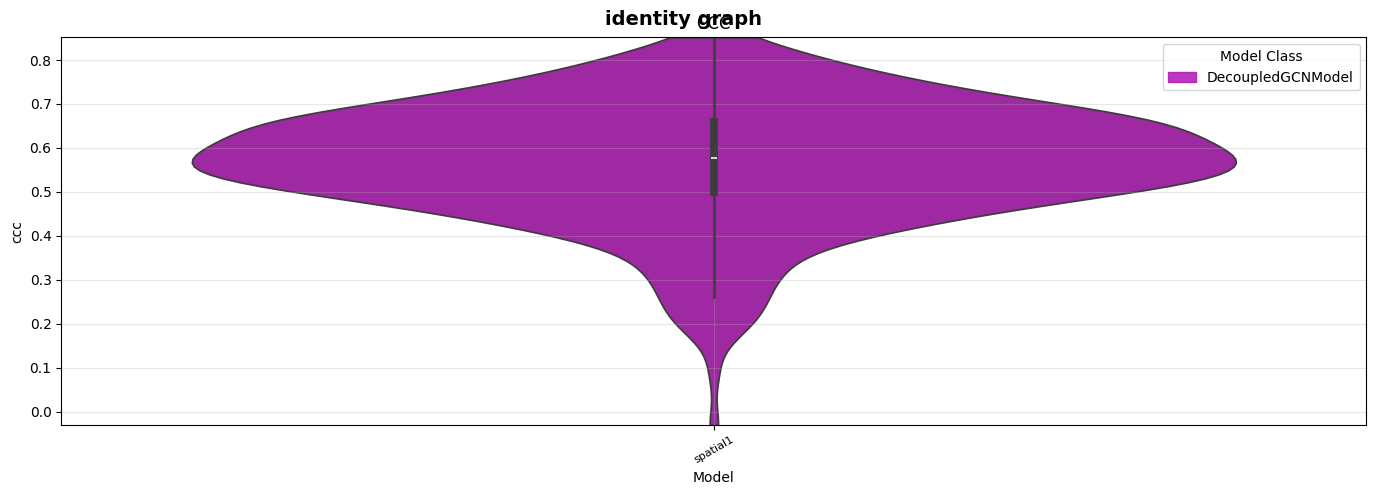

In [18]:
figure_raw1.show()

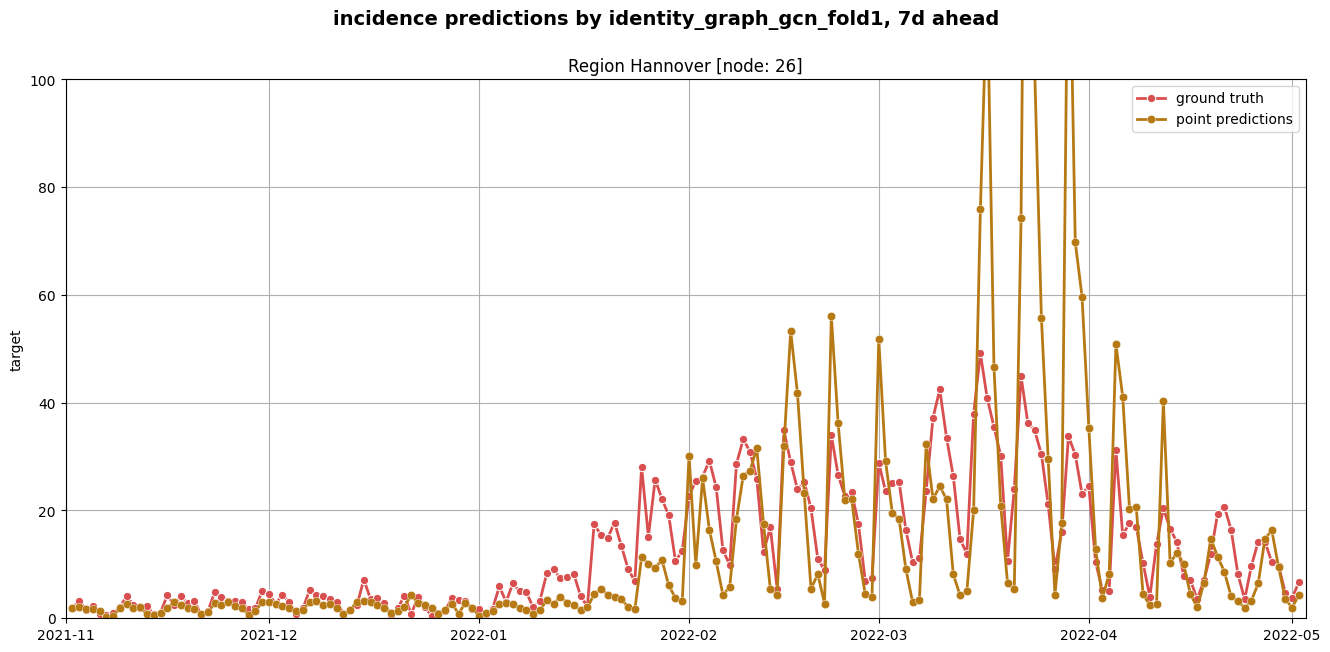

In [26]:
igs[0].show_forecasts(26).layout.set_ylim([0,100]).show()

In [28]:
igs[0].forecast('val')

Forecasting val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 184/184 [00:00<00:00, 560.21it/s]

Val loss: 0.2562
forecasted ✓


SimpleGCNModel(name='identity_graph_gcn_fold1')

In [29]:
gns[0].forecast('val')

Forecasting val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 184/184 [00:00<00:00, 548.46it/s]

Val loss: 0.2420
forecasted ✓


SimpleGCNModel(name='geo-neighbors_graph_gcn_fold1')

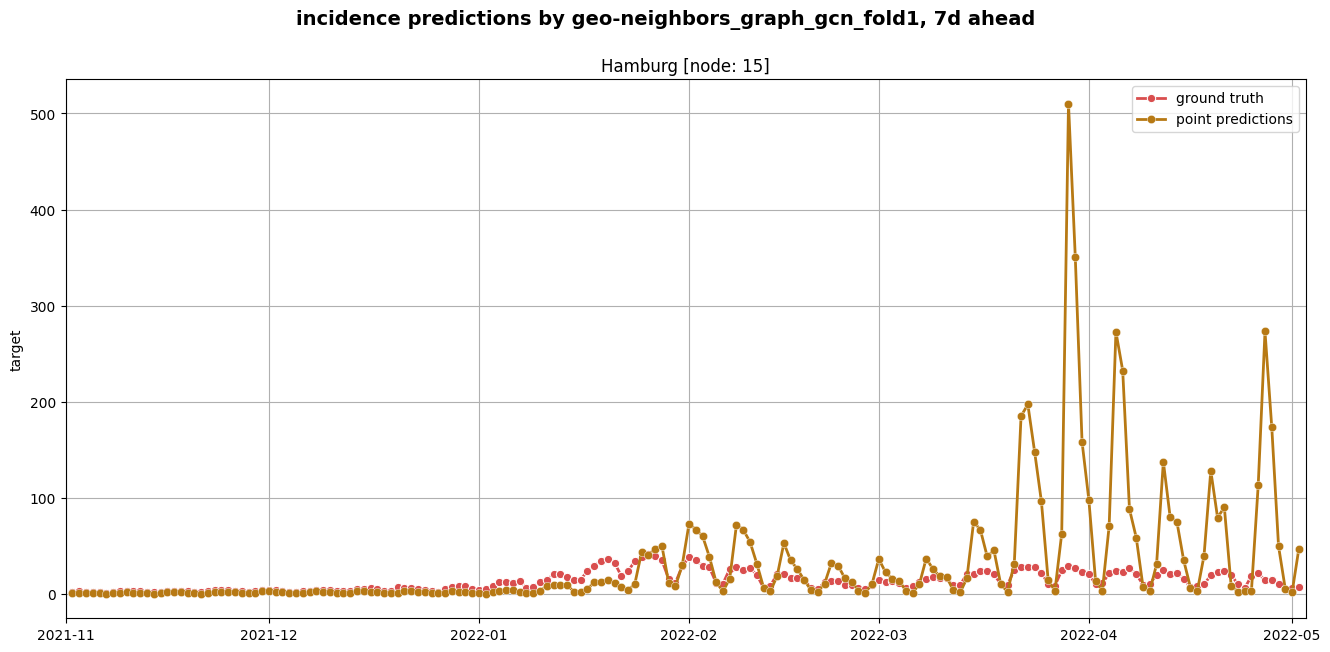

In [32]:
gns[0].show_forecasts(15).show()

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


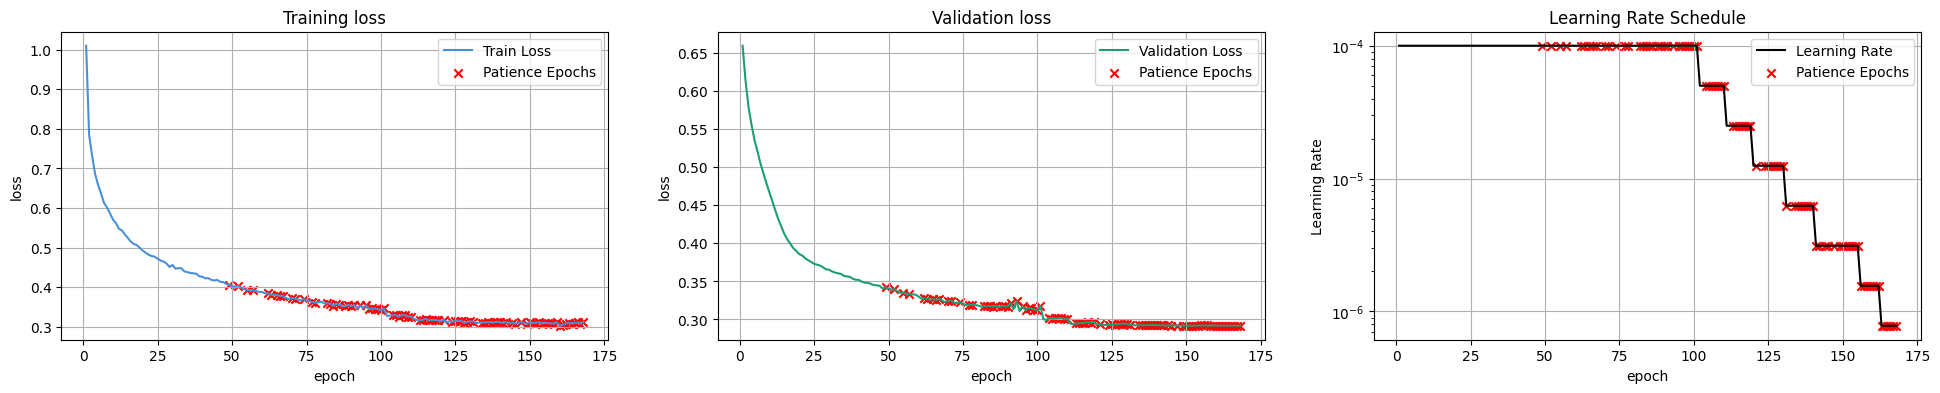

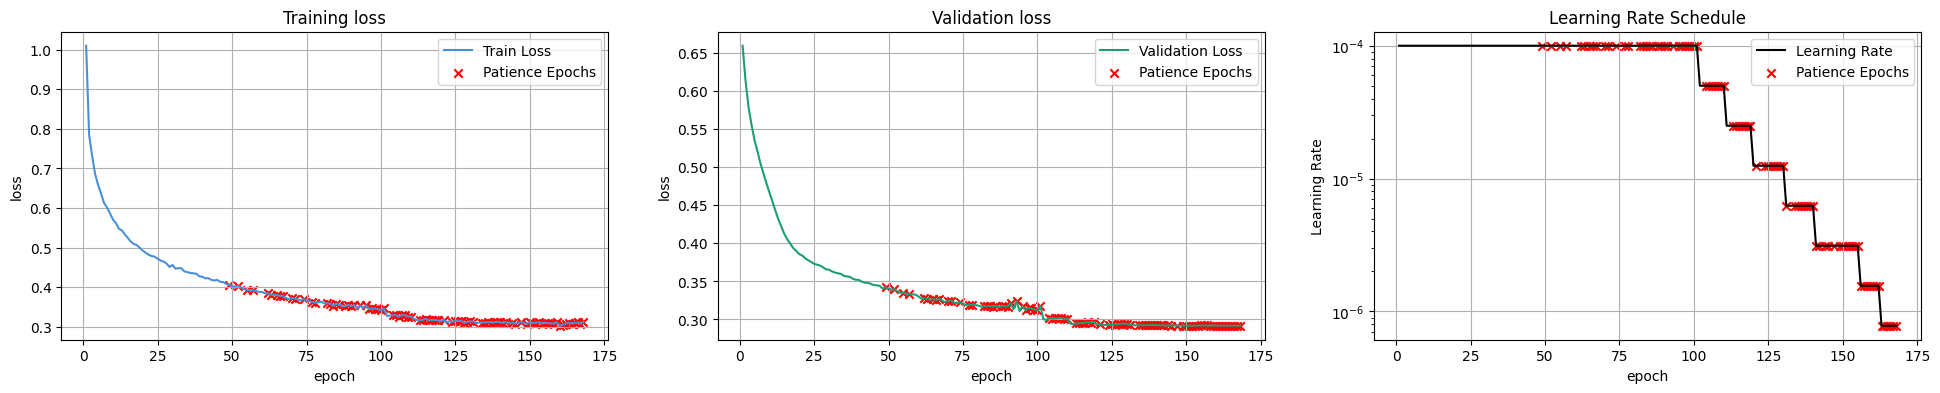

In [27]:
gns[5].show_monitoring_metrics()